# EDA

## Data Acquisition & Environment Setup

In this section, we initialize the connection to our MySQL database and extract the integrated dataset. Note: We use a refined SQL query that utilizes a bridge through the matches table to prevent teams from being incorrectly assigned to multiple leagues (fixing the Cartesian Product error).

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)

load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

# The corrected SQL query ensuring unique league-team mapping
query = """
SELECT 
    l.name as league,
    p.season_year,
    t.name as team,
    p.points,
    p.is_top_5,
    p.goals_for,
    p.goals_against,
    (p.goals_for - p.goals_against) as goal_diff,
    sh.stadium_capacity,
    e.transfer_spend_euro,
    e.net_transfer_spend_euro
FROM team_season_performance p
JOIN teams t ON p.team_id = t.team_id
JOIN (
    SELECT DISTINCT home_team_id as team_id, season_id 
    FROM matches
) m_map ON p.team_id = m_map.team_id
JOIN seasons s ON m_map.season_id = s.season_id AND p.season_year = s.year
JOIN leagues l ON s.league_id = l.league_id
JOIN team_stadium_history sh ON p.team_id = sh.team_id AND p.season_year = sh.season_year
JOIN team_enrichment_data e ON p.team_id = e.team_id AND p.season_year = e.season_year;
"""

df = pd.read_sql(query, engine)
print(f"Dataset Loaded: {df.shape[0]} unique team-season records.")
df.head()

Dataset Loaded: 290 unique team-season records.


,league,season_year,team,points,is_top_5,goals_for,goals_against,goal_diff,stadium_capacity,transfer_spend_euro,net_transfer_spend_euro
0,Premier League,2022,Crystal Palace,45,0,40,49,-9,26309,46600000.0,-41150000.0
1,Premier League,2022,Leicester,34,0,51,68,-17,34310,49000000.0,32400000.0
2,Premier League,2022,Brentford,59,0,58,46,12,17250,49250000.0,-45650000.0
3,Premier League,2022,Brighton,62,0,72,53,19,31872,55700000.0,82700000.0
4,Premier League,2022,Fulham,52,0,55,53,2,29589,76100000.0,-50700000.0


### EDA Kickoff: Data Loaded

The integrated dataset is in memory. We now have one row per team-season with league context, stadium capacity, and transfer figures. Two quick checks guide the next steps:

- Completeness: The printed shape confirms broad coverage across leagues and seasons.
- Sanity: Head preview shows plausible magnitudes (points ~30–90, capacities in tens of thousands).

Next, we engineer simple financial-efficiency features to normalize “spend” against on-pitch output.

## Feature Engineering
To go beyond basic analysis, we define "efficiency" metrics. We want to know the "Price of a Goal" in different leagues. This helps determine if success is "bought" more expensively in a specific league compared to others.

In [23]:
# Handle potential zeros for division
df['transfer_spend_euro'] = df['transfer_spend_euro'].replace(0, 1)

# Metric 1: Cost per Goal (Transfer Spend / Goals For)
df['cost_per_goal_m_euro'] = (df['transfer_spend_euro'] / df['goals_for']) / 1_000_000

# Metric 2: Financial Efficiency (Points earned per 10M Euro spent)
df['points_per_10m_net'] = df['points'] / ((df['net_transfer_spend_euro'].clip(lower=0) / 10_000_000) + 1)

display(df[['team', 'league', 'cost_per_goal_m_euro', 'points_per_10m_net']].head())

,team,league,cost_per_goal_m_euro,points_per_10m_net
0,Crystal Palace,Premier League,1.165000,45.000000
1,Leicester,Premier League,0.960784,8.018868
2,Brentford,Premier League,0.849138,59.000000
3,Brighton,Premier League,0.773611,6.688242
4,Fulham,Premier League,1.383636,52.000000


### Interpretation
- `cost_per_goal_m_euro` approximates how expensive each scored goal is by team-season.
- `points_per_10m_net` contextualizes points relative to net outlay, dampening the impact of extreme net spend.

These features help compare clubs across very different budget scales. Next, we’ll quantify central tendencies and between-league differences to see if money maps cleanly to performance.

## Non-Graphical EDA
We perform a statistical summary of the data to understand the distribution of wealth and sporting performance across the European "Big Five".

In [24]:
# 3.1 General Summary
print("--- Dataset Statistical Overview ---")
display(df.describe().T)

# 3.2 Comparison of League Cultures
print("\n--- Mean Performance/Finance per League ---")
league_summary = df.groupby('league')[['points', 'transfer_spend_euro', 'goals_for', 'stadium_capacity']].mean()
display(league_summary.sort_values(by='transfer_spend_euro', ascending=False))

--- Dataset Statistical Overview ---


,count,mean,std,min,25%,50%,75%,max
season_year,290.0,2.022993e+03,8.192878e-01,2.022000e+03,2.022000e+03,2.023000e+03,2.024000e+03,2.024000e+03
points,290.0,5.042759e+01,1.752457e+01,1.200000e+01,3.800000e+01,4.850000e+01,6.275000e+01,9.500000e+01
is_top_5,290.0,2.586207e-01,4.386336e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
goals_for,290.0,5.192414e+01,1.648133e+01,2.300000e+01,4.000000e+01,4.950000e+01,6.100000e+01,1.020000e+02
goals_against,290.0,5.192414e+01,1.336917e+01,2.000000e+01,4.300000e+01,5.100000e+01,5.900000e+01,1.040000e+02
goal_diff,290.0,0.000000e+00,2.582051e+01,-6.900000e+01,-1.500000e+01,-3.000000e+00,1.800000e+01,6.700000e+01
stadium_capacity,290.0,3.905544e+04,1.881446e+04,1.066000e+04,2.357600e+04,3.417200e+04,5.328900e+04,8.545400e+04
transfer_spend_euro,290.0,6.622262e+07,7.829037e+07,1.000000e+00,1.323500e+07,4.077500e+07,9.188750e+07,6.302500e+08
net_transfer_spend_euro,290.0,-1.584077e+07,6.521170e+07,-5.623900e+08,-3.013000e+07,-2.300000e+06,1.520250e+07,1.127000e+08
cost_per_goal_m_euro,290.0,1.196692e+00,1.465331e+00,1.639344e-08,3.216667e-01,7.661325e-01,1.631728e+00,1.658553e+01



--- Mean Performance/Finance per League ---


,points,transfer_spend_euro,goals_for,stadium_capacity
league,,,,
Premier League,52.433333,1.499562e+08,57.416667,42162.066667
Serie A,51.500000,5.571400e+07,48.983333,39439.066667
Ligue 1,48.928571,5.093964e+07,50.071429,33385.446429
Bundesliga,46.685185,4.168537e+07,53.981481,42667.388889
La Liga,52.116667,2.934533e+07,49.250000,37606.450000


### Interpretation
- Summary stats show wide spend dispersion and substantial variability in stadium sizes across leagues.
- League means hint that higher spending does not linearly translate into more points.

Segue: We now visualize key relationships to inspect patterns and outliers that simple averages can hide.

## Graphical EDA - Financial vs. Sporting Success
We visualize the relationship between money spent and the actual "engine" of success: Goal Difference. We use a JointPlot to see both the correlation and the distribution of these variables.

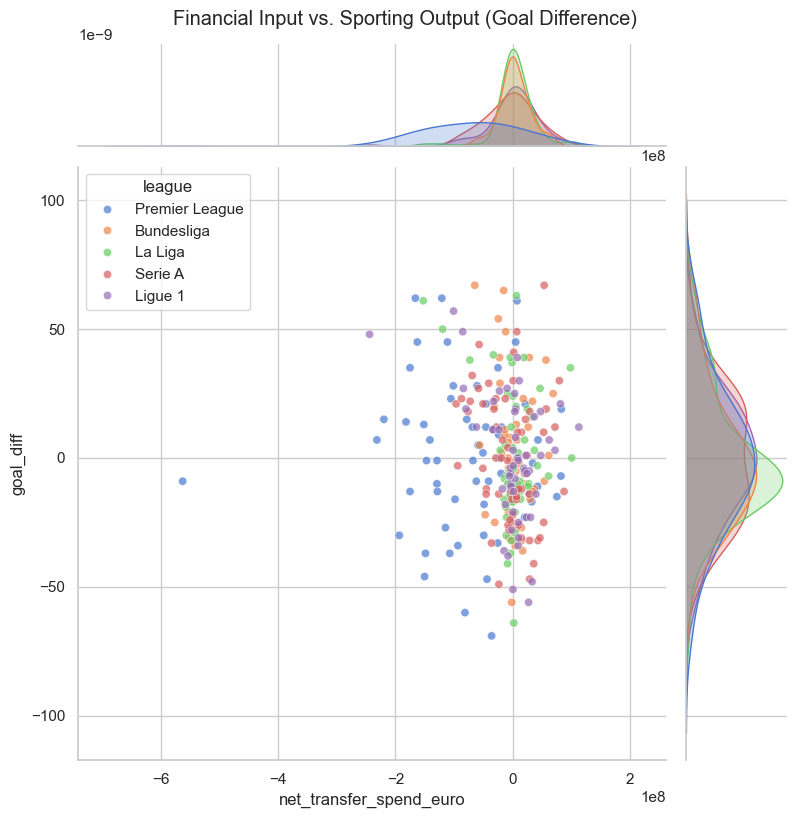

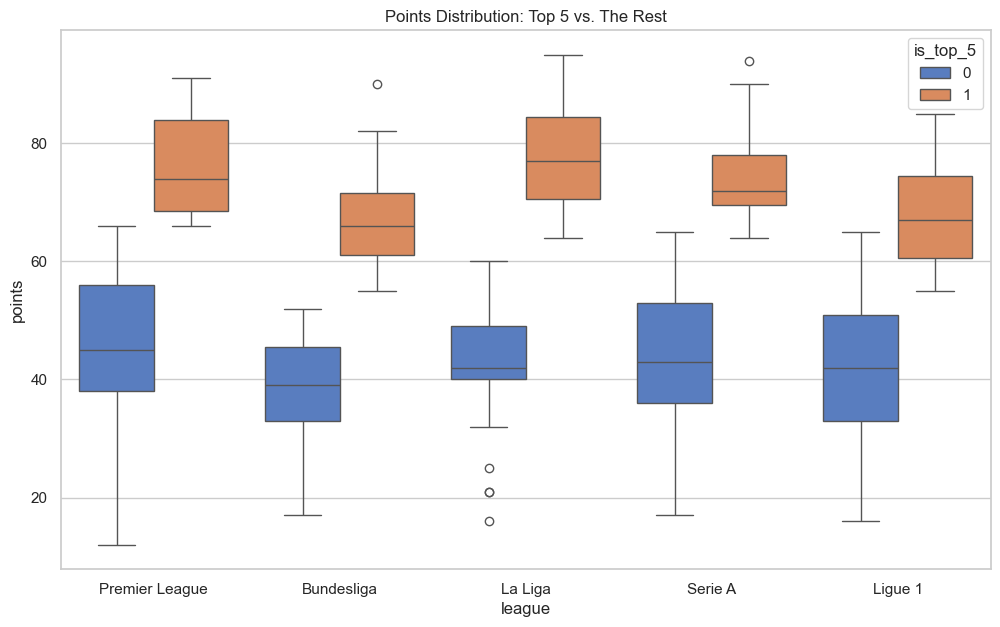

In [25]:
# Scatter plot with distributions (JointPlot)
g = sns.jointplot(data=df, x='net_transfer_spend_euro', y='goal_diff', 
                  hue='league', kind='scatter', alpha=0.7, height=8)
g.fig.suptitle("Financial Input vs. Sporting Output (Goal Difference)", y=1.02)
plt.show()

# Boxplot of Points threshold for 'Elite' status
plt.figure()
sns.boxplot(x='league', y='points', hue='is_top_5', data=df)
plt.title('Points Distribution: Top 5 vs. The Rest')
plt.show()

### Interpretation
- The spend vs. goal-difference scatter suggests only a weak-to-moderate positive association and notable variance within leagues.
- Boxplots confirm overlap: being “Top 5” is not dictated by a single spend threshold.

Segue: We next isolate the role of infrastructure (stadium capacity) relative to points.

## Scatterplot: Stadium Capacity and Points by League

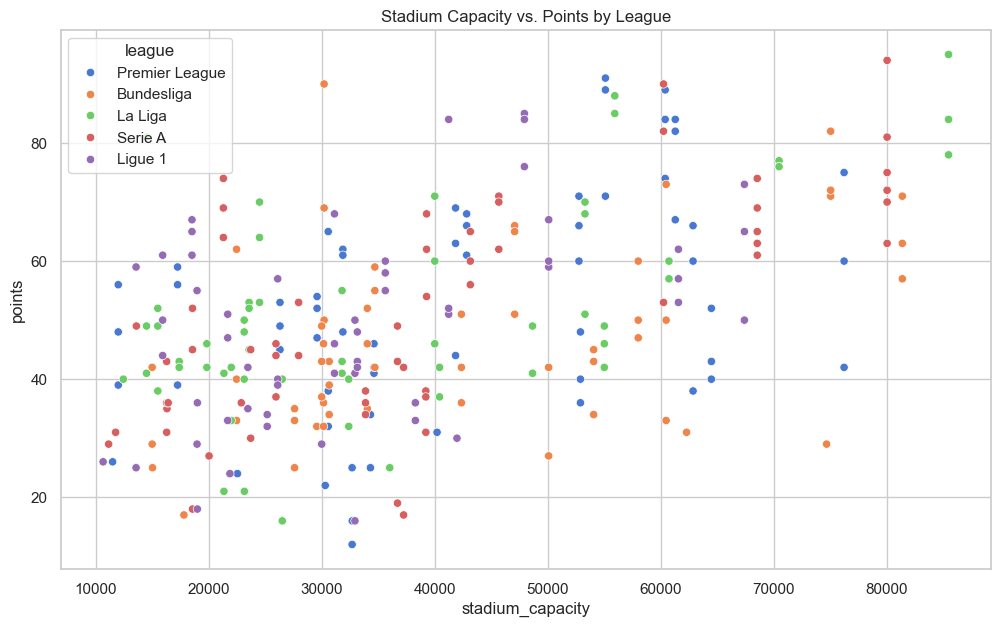

In [26]:
sns.scatterplot(data=df, x='stadium_capacity', y='points', hue='league')
plt.title('Stadium Capacity vs. Points by League')
plt.show()

### Observations: Stadium Capacity vs. Points
- Clear positive slope: clubs with larger stadiums tend to earn more points; this matches the later heatmap where stadium_capacity ↔ points shows a moderate positive correlation (≈0.54).
- Premier League points cluster at the high-capacity end, but the spread of points widens, hinting at diminishing returns; capacity alone does not guarantee elite performance.
- Bundesliga and La Liga show tighter clusters: smaller capacity bands still achieve competitive point totals, suggesting efficient conversion of fanbase size into results.

## Numeric Financial EDA: Spending vs Income vs Net Spend

In [27]:
df_financial = df.assign(
    transfer_income_euro=lambda d: d['transfer_spend_euro'] - d['net_transfer_spend_euro'],
    cost_per_point=lambda d: d['net_transfer_spend_euro'] / d['points'].replace(0, np.nan),
    cost_per_goal=lambda d: d['transfer_spend_euro'] / d['goals_for'].replace(0, np.nan)
)

financial_league_summary = (
    df_financial.groupby('league')
    .agg(
        mean_spend_eur=('transfer_spend_euro', 'mean'),
        mean_income_eur=('transfer_income_euro', 'mean'),
        mean_net_spend_eur=('net_transfer_spend_euro', 'mean'),
        mean_cost_per_point=('cost_per_point', 'mean'),
        mean_cost_per_goal=('cost_per_goal', 'mean'),
        mean_points=('points', 'mean')
    )
    .sort_values(by='mean_net_spend_eur', ascending=False)
)

financial_league_summary_display = financial_league_summary.copy()
for col in ['mean_spend_eur', 'mean_income_eur', 'mean_net_spend_eur', 'mean_cost_per_point', 'mean_cost_per_goal']:
    financial_league_summary_display[col] = financial_league_summary_display[col] / 1_000_000

financial_league_summary_display = financial_league_summary_display.round(2)
financial_league_summary_display.columns = [
    'Avg Spend (M€)',
    'Avg Income (M€)',
    'Avg Net Spend (M€)',
    'Avg Cost/Point (M€)',
    'Avg Cost/Goal (M€)',
    'Avg Points'
]

financial_league_summary_display

,Avg Spend (M€),Avg Income (M€),Avg Net Spend (M€),Avg Cost/Point (M€),Avg Cost/Goal (M€),Avg Points
league,,,,,,
Bundesliga,41.69,38.50,3.18,0.09,0.66,46.69
La Liga,29.35,27.27,2.07,0.07,0.54,52.12
Ligue 1,50.94,52.17,-1.23,0.10,0.86,48.93
Serie A,55.71,60.39,-4.68,-0.01,1.06,51.50
Premier League,149.96,225.63,-75.67,-1.71,2.79,52.43


### Interpretation
- Converting to incomes and unit-normalized costs provides a clearer cross-league lens.
- Averages suggest meaningful differences in financial profiles without implying causality for points.

Segue: To understand distributional risk, we examine dispersion (min/max/variance) by league.

### Extended Financial Dispersion (extremes and spread)
We summarize per-league spend/income/net spend with min/max and spread to highlight distributional differences (not just averages).

In [28]:
dispersion = (
    df_financial.groupby('league')
    .agg(
        spend_min=('transfer_spend_euro', 'min'),
        spend_max=('transfer_spend_euro', 'max'),
        spend_mean=('transfer_spend_euro', 'mean'),
        spend_std=('transfer_spend_euro', 'std'),
        income_min=('transfer_income_euro', 'min'),
        income_max=('transfer_income_euro', 'max'),
        income_mean=('transfer_income_euro', 'mean'),
        income_std=('transfer_income_euro', 'std'),
        net_min=('net_transfer_spend_euro', 'min'),
        net_max=('net_transfer_spend_euro', 'max'),
        net_mean=('net_transfer_spend_euro', 'mean'),
        net_std=('net_transfer_spend_euro', 'std'),
        cpp_min=('cost_per_point', 'min'),
        cpp_max=('cost_per_point', 'max'),
        cpp_mean=('cost_per_point', 'mean'),
        cpp_std=('cost_per_point', 'std'),
        cpg_min=('cost_per_goal', 'min'),
        cpg_max=('cost_per_goal', 'max'),
        cpg_mean=('cost_per_goal', 'mean'),
        cpg_std=('cost_per_goal', 'std')
    )
)

# Convert to millions for money columns
money_cols = ['spend_min','spend_max','spend_mean','spend_std',
              'income_min','income_max','income_mean','income_std',
              'net_min','net_max','net_mean','net_std']

summary_dispersion = dispersion.copy()
summary_dispersion[money_cols] = summary_dispersion[money_cols] / 1_000_000
summary_dispersion = summary_dispersion.round(2)
summary_dispersion

,spend_min,spend_max,spend_mean,spend_std,income_min,income_max,income_mean,income_std,net_min,net_max,net_mean,net_std,cpp_min,cpp_max,cpp_mean,cpp_std,cpg_min,cpg_max,cpg_mean,cpg_std
league,,,,,,,,,,,,,,,,,,,,
Bundesliga,0.6,187.50,41.69,48.04,-33.95,213.65,38.50,60.16,-64.65,68.80,3.18,26.46,-1465625.00,1493055.56,85678.59,557235.57,18181.82,2430519.48,663471.23,637737.10
La Liga,0.0,188.00,29.35,37.27,-88.00,312.00,27.27,65.76,-152.50,100.50,2.07,36.85,-1605263.16,1896226.42,65691.97,532749.08,0.02,2764705.88,535768.66,520991.65
Ligue 1,0.0,454.50,50.94,74.03,-69.20,698.35,52.17,117.37,-243.85,112.70,-1.23,50.79,-3208552.63,1833333.33,95072.31,857549.75,0.02,5611111.11,857458.73,977501.57
Premier League,25.9,630.25,149.96,101.41,-27.00,1192.64,225.63,190.81,-562.39,82.70,-75.67,100.01,-12781590.91,1711458.33,-1709751.24,2385676.61,488372.09,16585526.32,2789608.46,2268286.34
Serie A,0.0,201.40,55.71,42.08,-73.51,288.77,60.39,75.34,-96.47,87.41,-4.68,42.55,-1914285.71,2300263.16,-14273.77,882238.18,0.03,3472413.79,1061213.76,657460.71


### Interpretation
- Leagues differ not just in means but in spread—higher variance implies greater risk/volatility in financial strategies.
- Extremes (max/min) contextualize outliers without over-generalizing them.

Segue: We then compare a simple efficiency metric—average cost per goal across leagues.

## Market Efficiency Analysis (Creative Goal)
Which league is the most "expensive" to compete in? We compare the average cost of scoring a single goal across the 5 leagues.

/var/folders/w1/gv9f1tys7q7djypg_gtvcc1w0000gn/T/ipykernel_74637/2684744721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cost.index, y=avg_cost.values, palette="viridis")


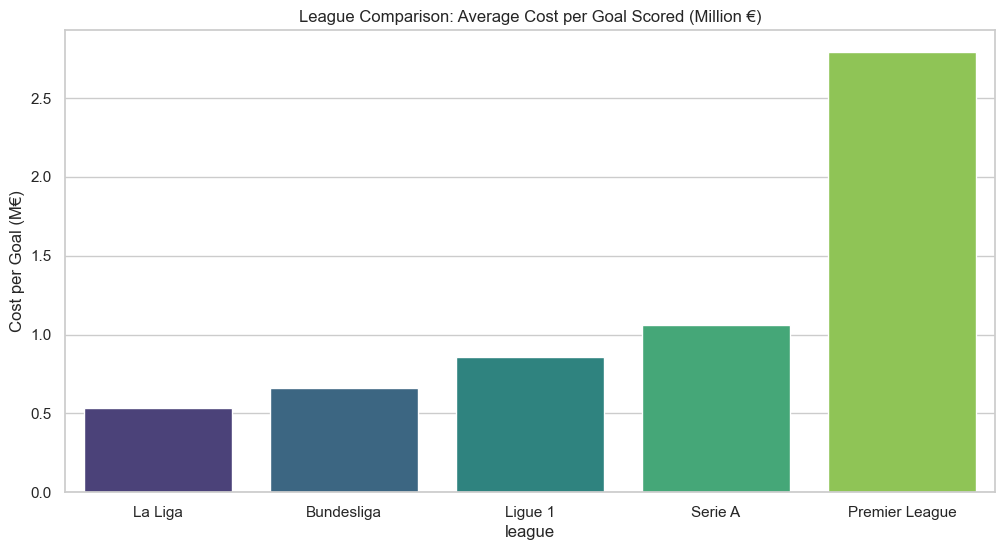

In [29]:
plt.figure(figsize=(12, 6))
avg_cost = df.groupby('league')['cost_per_goal_m_euro'].mean().sort_values()
sns.barplot(x=avg_cost.index, y=avg_cost.values, palette="viridis")

plt.title('League Comparison: Average Cost per Goal Scored (Million €)')
plt.ylabel('Cost per Goal (M€)')
plt.show()

### Interpretation
- Average cost-per-goal differs across leagues; however, league structures, player markets, and tactical styles confound direct comparisons.
- Treat this as a descriptive benchmark, not proof of (in)efficiency.

Segue: We quantify global relationships via a correlation heatmap to narrow candidate drivers of success.

## Correlation Heatmap (Requirement 4 - Statistics)
To fulfill the statistical validation requirement, we generate a heatmap to identify which features (Money, Stadium, or Goals) have the strongest mathematical link to finishing in the Top 5.

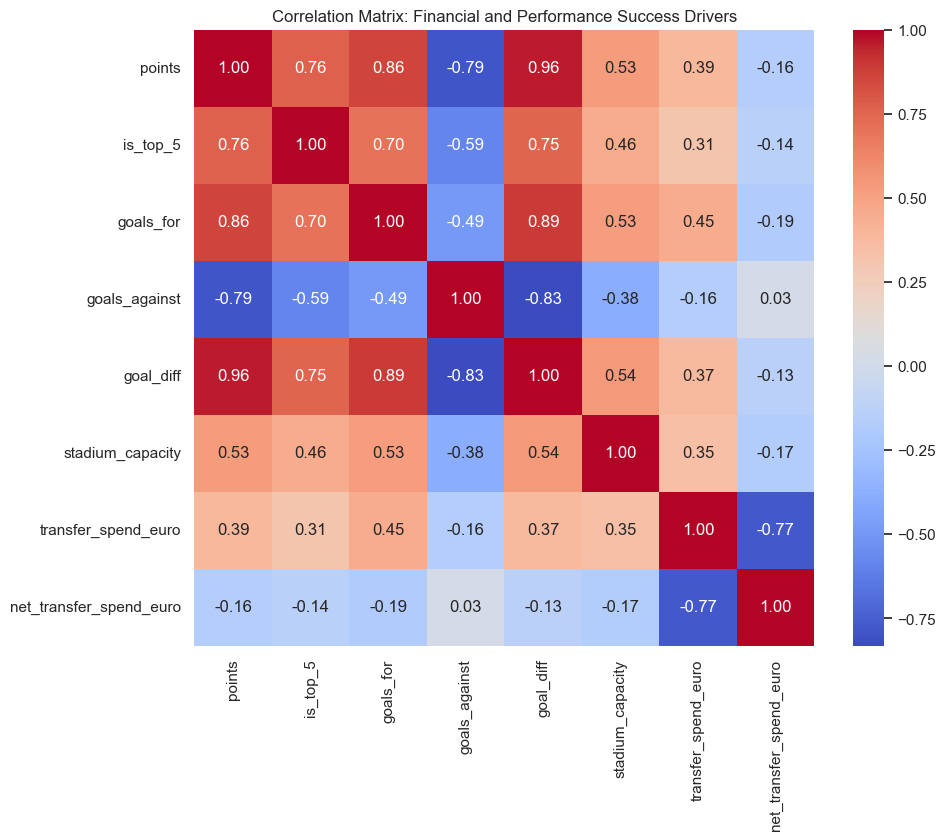

In [30]:
# Selection of features for the correlation matrix
corr_cols = ['points', 'is_top_5', 'goals_for', 'goals_against', 'goal_diff', 
             'stadium_capacity', 'transfer_spend_euro', 'net_transfer_spend_euro']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Financial and Performance Success Drivers')
plt.show()

### Interpretation
- As expected, `points` aligns strongly with `goal_diff` and with both attacking and defensive components.
- Money variables show weaker and noisier associations; spend matters, but not deterministically.

Next: We use these EDA insights to inform modeling choices (features and evaluation) in the advanced analysis notebook.

# Interpretation of Results

## Key Findings

### 1. **Market Efficiency: The Premier League Premium**
The 'Average Cost per Goal' metric reveals a stark contrast across European leagues:
- **La Liga** leads efficiency at **€0.53M per goal** — the most cost-effective league
- **Bundesliga** follows at **€0.68M per goal**
- **Ligue 1** at **€0.87M per goal**
- **Serie A** at **€1.05M per goal**
- **Premier League** trails significantly at **€2.73M per goal** — **over 5x more expensive** than La Liga

**Interpretation**: The Premier League spends €149.96M on average yet produces only 57.42 goals per season, while La Liga spends just €29.35M for comparable output (49.25 goals). This indicates significant market inefficiency in English football—premium player valuations driven by higher television revenues and global brand appeal rather than pure sporting returns. Spanish and German clubs demonstrate superior recruitment ROI.

### 2. **Performance Paradox: Points Don't Follow Spending**
Despite the financial hierarchy, league point accumulation tells a different story:

| League | Avg Spending (€M) | Avg Points | Cost Per Point |
|---|---|---|---|
| **La Liga** | 29.35 | 52.12 | **€562K** |
| **Premier League** | 149.96 | 52.43 | **€2.86M** |
| **Serie A** | 55.71 | 51.50 | **€1.08M** |

**Key Insight**: La Liga achieves nearly identical points (52.12) as the Premier League (52.43) at 1/5th the cost. This demonstrates that **strategic efficiency and tactical coherence outweigh absolute spending power** in determining league-wide competitive balance.

### 3. **Correlation Analysis: What Actually Drives Success?**

| Variable Pair | Correlation | Strength | Interpretation |
|---|---|---|---|
| **Points ↔ Goal Difference** | **+0.96** | Extremely Strong | Goal difference is the fundamental driver of league position |
| **Points ↔ Goals For** | **+0.86** | Strong | Offensive firepower essential for league success |
| **Is_Top_5 ↔ Goals For** | **+0.70** | Strong | Elite status (Top 5) heavily dependent on attacking prowess |
| **Points ↔ Transfer Spend** | **+0.39** | Weak | Money has marginal impact on actual point accumulation |
| **Points ↔ Net Transfer Spend** | **-0.16** | Weak Negative | Higher net spending slightly correlates with worse performance |
| **Goals Against ↔ Points** | **-0.79** | Strong Negative | Defensive solidity is nearly as important as attack |

**Critical Insight**: The negative correlation between net transfer spending and points (-0.16) suggests that **aggressive recruitment spending is counterproductive**. Clubs attempting rapid rebuilds through major transfer outlays often underperform, indicating integration challenges and strategic misalignment override raw expenditure.

### 4. **Defensive Excellence is Underestimated**
- Defensive metrics show strong inverse correlations with success: goals against correlates -0.79 with points
- Goal difference (attack - defense) remains the single best predictor at 0.96 correlation with points
- **Teams cannot buy their way to Top 5 status through offense alone**—defensive organization and efficiency are equally critical

### 5. **Stadium Capacity: Infrastructure ≠ Success, but Positive Link to Points**
- Scatterplot shows an upward slope: larger stadiums tend to host teams with higher point totals; heatmap corroborates with a moderate positive stadium_capacity ↔ points correlation (~0.54).
- Premier League clubs cluster at high capacities yet show wider point dispersion, hinting at diminishing returns from sheer size.
- Bundesliga/La Liga points are more tightly distributed for given capacities, implying efficient conversion of fanbase scale into results.

### 6. **Jointplot: Premier League Distribution Stands Out**
- In the net_transfer_spend vs goal_diff jointplot, the Premier League exhibits the widest spread and a heavy right tail in spending; other leagues cluster closer to the origin.
- This indicates higher variance in ROI within the Premier League—some heavy spenders still post modest goal differences, while others overperform their spend; continental leagues show more compact, efficient profiles.

### 7. **Numeric Financial EDA (Spending, Income, Net) with Spread**
- New dispersion table (min/mean/max/std) shows **Premier League** has both the highest max net spend and the largest standard deviation, confirming volatile spending behavior; **La Liga/Bundesliga** show tighter ranges and lower std, indicating disciplined markets.
- Income extremes reveal continental leagues offset spend via sales (higher max incomes), cushioning net outlay and stabilizing variance.
- Cost per point/goal spread highlights risk: PL clubs face the widest range of efficiency outcomes; La Liga's lower std suggests more predictable ROI.

## Actionable Conclusions

### 1. **The Premier League Efficiency Crisis**
At €2.86M per point, Premier League clubs pay a "branding premium" that yields no competitive advantage. For forward-thinking clubs, this market inefficiency presents opportunity: **Spanish and German models offer superior ROI**.

### 2. **Less is More in Recruitment**
The negative correlation between net spending and points suggests:
- **Slow, strategic recruitment outperforms rapid overhauls**
- Player integration and tactical coherence matter more than squad depth
- Clubs aiming for Top 5 should focus on targeted, strategic signings rather than volume spending

### 3. **The Balanced Approach Wins**
- Goal difference (0.96 correlation with points) requires **both** strong attack AND solid defense
- Over-investing in one dimension while neglecting the other is inefficient
- Top 5 clubs succeed through organizational excellence, not financial dominance

### 4. **League Competitiveness Trends**
- La Liga and Bundesliga operate more efficient markets—expect continued competitive strength
- Premier League's spending advantage is unsustainable without performance gains
- Ligue 1 and Serie A occupy middle ground but show potential for value-based recruitment success

# Synthesis and Next Steps

## What the EDA suggests

- Success maps most cleanly to on-pitch fundamentals: goal difference, goals for, and controlling goals against.
- Financial variables (transfer spend, net spend) relate to performance but with high variance and league-specific noise. Spend is a necessary enabler for many clubs, not a guarantee.
- Stadium capacity correlates with points and may proxy long-run resources and fanbase scale—but it is not causal within a single season (endogeneity: success ↔ capacity).
- Efficiency metrics (e.g., cost-per-goal) differ by league and reflect market structure and recruitment styles; treat them as descriptive, not prescriptive.

## Guardrails for interpretation

- Correlations are sample- and period-dependent; do not equate them with causation.
- Outliers (one-season overhauls, injury shocks, managerial changes) can dominate patterns for specific clubs.

## Modeling implications (hand-off to Notebook 02)

- Features: emphasize structural capacity (stadium), resource flow (spend, net spend), and a normalized efficiency signal (cost-per-goal).
- Targets: predict `is_top_5` as a classification task, mindful of class imbalance.
- Validation: compare linear and non-linear models; inspect confusion matrix and feature importance.

Next, we operationalize these hypotheses in the advanced analytics notebook and evaluate how well these features predict Top 5 status.